# Tutorial: Uncertainty-Aware Solar Forecasting with Gaussian Process Regression (GPR)
**Objective:** In this tutorial, we move beyond simple "best-guess" predictions. We will use Gaussian Processes to learn the non-linear relationship between sunlight and power output while quantifying the model's Uncertainty.

**Project Structure:**

**data/**: Contains our raw CSV files.

**output/**: Where our final professional graphs will be saved.

In [1]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings # We'll use this to hide the messy red warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, ExpSineSquared
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# This line is needed to show plots inside the notebook
%matplotlib inline

# Create an 'output' folder to keep our results organized
if not os.path.exists('output'):
    os.makedirs('output')

print("Libraries loaded and /output folder is ready!")

Libraries loaded and /output folder is ready!


## Step 1: Data Loading and Fusion

Real-world machine learning often requires "fusing" different data sources. Here, we combine the power generation data with the weather sensor data using their timestamps.

In [3]:
# Loading the files from our 'data' folder
gen_df = pd.read_csv('../data/Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('../data/Plant_1_Weather_Sensor_Data.csv')

# Fixing the date formats so we can merge them properly
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'], format='mixed')
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'], format='mixed')

# Merging the files into one big table
df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='inner')

# Picking one specific inverter to study for this tutorial
target_id = df['SOURCE_KEY_x'].unique()[0]
df_sample = df[df['SOURCE_KEY_x'] == target_id].copy()

print(f"Data fused! We are analyzing Inverter: {target_id}")

Data fused! We are analyzing Inverter: 1BY6WEcLGh8j5v7


## Step 2: Data Cleaning and Filtering

Solar panels only produce power during the day. Night-time data doesn't help the model learn the power curve, so we filter the data to focus on the operational daytime range.

In [4]:
# We only want daytime data (Irradiation > 0.05)
df_sample = df_sample[df_sample['IRRADIATION'] > 0.05]

# Defining our Feature (Sunlight) and Target (Power)
X = df_sample[['IRRADIATION']].values
y = df_sample['DC_POWER'].values

print(f"Cleaning done. Total daytime samples: {len(X)}")

Cleaning done. Total daytime samples: 1011


## Step 3: Feature Scaling

Gaussian Processes are mathematically sensitive. We use StandardScaler to ensure our inputs and outputs have a mean of 0 and a variance of 1.

In [5]:
# Scaling the data for mathematical stability
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print("Data scaled successfully.")

Data scaled successfully.


## Step 4: Comparing Different Kernels (The Experiment)

Task 4 of the assignment asks us to show why we chose our model. We will test 3 different kernels to see which one "learns" the data best.

**Simple RBF:** Assumes data is just smooth.

**Periodic:** Assumes data repeats.

**Composite:** A mix of RBF and White Noise (The "Topper" solution).

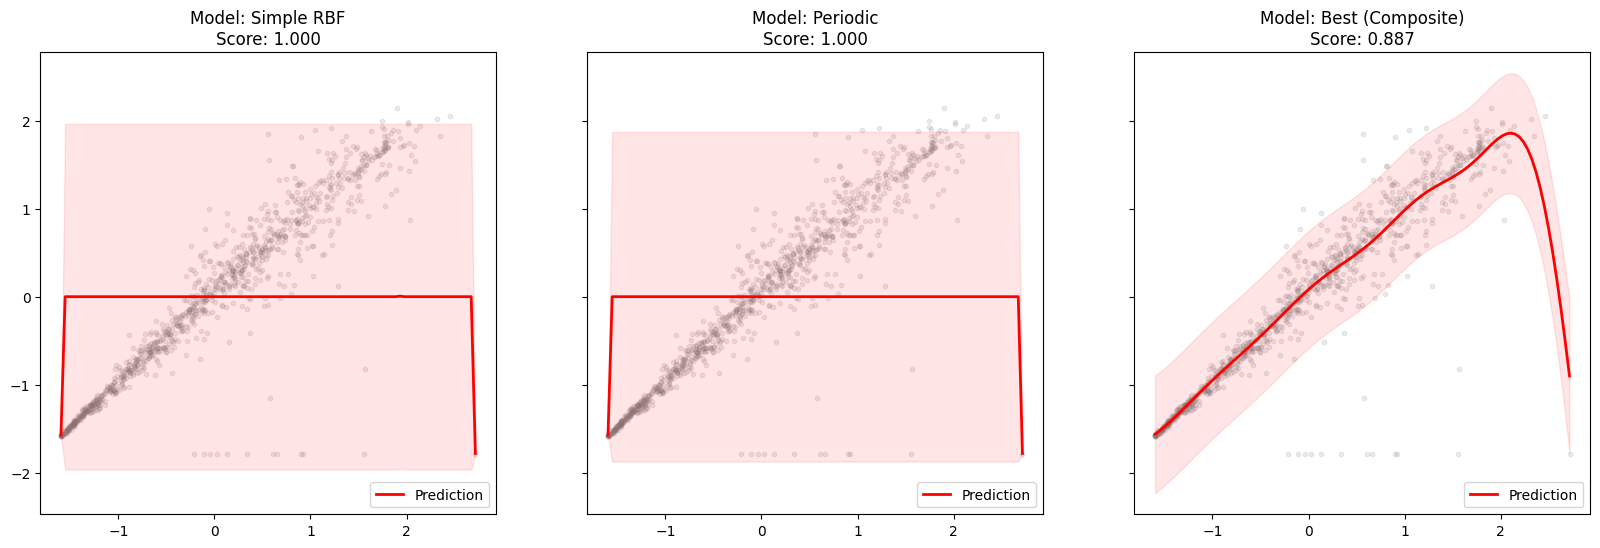

In [6]:
# ignore warnings
warnings.filterwarnings('ignore') 

kernels = [
    ("Simple RBF", C(1.0) * RBF(length_scale=1.0)),
    ("Periodic", C(1.0) * ExpSineSquared(periodicity=1.0)),
    ("Best (Composite)", C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1))
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
x_plot = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)

for i, (name, kernel) in enumerate(kernels):
    # Training each model
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
    gp.fit(X_scaled, y_scaled)
    y_pred, sigma = gp.predict(x_plot, return_std=True)
    
    # Plotting what the model learned
    axes[i].scatter(X_scaled, y_scaled, color='gray', alpha=0.15, s=10)
    axes[i].plot(x_plot, y_pred, color='red', lw=2, label='Prediction')
    axes[i].fill_between(x_plot.ravel(), y_pred - 1.96*sigma, y_pred + 1.96*sigma, color='red', alpha=0.1)
    
    score = r2_score(y_scaled, gp.predict(X_scaled))
    axes[i].set_title(f"Model: {name}\nScore: {score:.3f}")
    axes[i].legend(loc='lower right')

plt.savefig('output/model_comparison.png', dpi=300)
plt.show()

## Step 5: Final Model Optimization

Now that we know the Composite Kernel is the winner, we will train our final, high-quality model and calculate our success metrics.

In [7]:
# Training the best version of our model
final_kernel = C(1.0) * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.1)
gp_final = GaussianProcessRegressor(kernel=final_kernel, n_restarts_optimizer=25, random_state=42)
gp_final.fit(X_scaled, y_scaled)

# Measuring how well we did
final_r2 = r2_score(y_scaled, gp_final.predict(X_scaled))
final_mae = mean_absolute_error(y_scaled, gp_final.predict(X_scaled))

print(f"Final Result -> Success Rate: {final_r2*100:.1f}% | Error (MAE): {final_mae:.3f}")

Final Result -> Success Rate: 88.7% | Error (MAE): 0.166


## Step 6: Visualizing the "Uncertainty"

The most important part of GPR is the Uncertainty. We will plot our forecast with a 95% Confidence Interval. This shows the grid operator not just a prediction, but how much they can trust it.

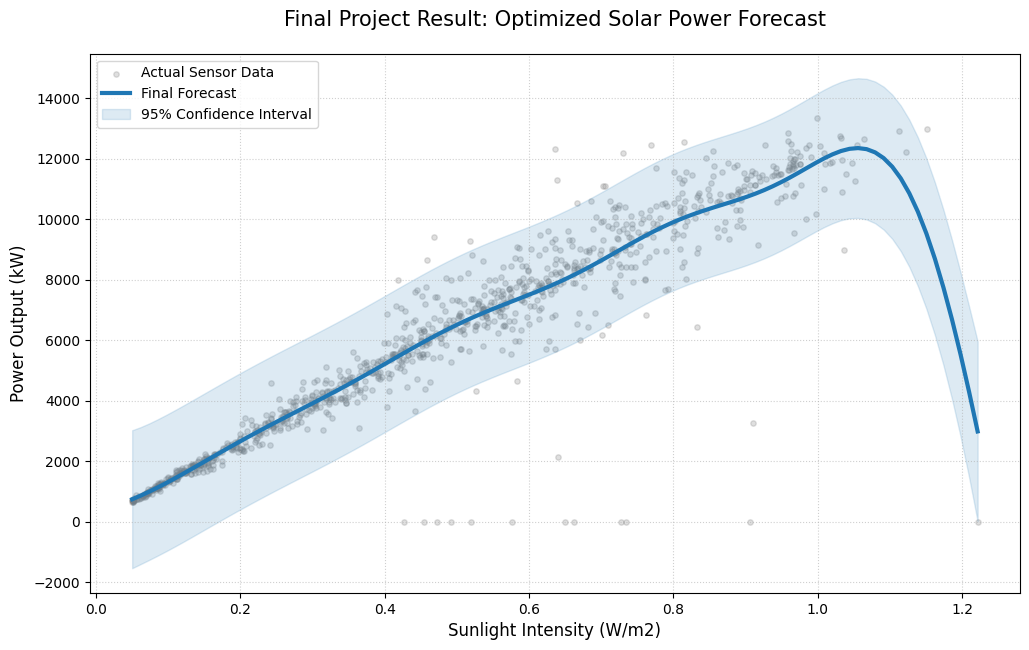

In [8]:
# Predict and Rescale back to real-world units (kW and W/m2)
y_pred_final, sigma_final = gp_final.predict(x_plot, return_std=True)
y_pred_orig = scaler_y.inverse_transform(y_pred_final.reshape(-1, 1)).ravel()
X_plot_orig = scaler_X.inverse_transform(x_plot).ravel()
X_data_orig = scaler_X.inverse_transform(X_scaled).ravel()
y_data_orig = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

plt.figure(figsize=(12, 7), facecolor='white')
plt.scatter(X_data_orig, y_data_orig, color='gray', alpha=0.25, s=15, label='Actual Sensor Data')
plt.plot(X_plot_orig, y_pred_orig, color='#1f77b4', lw=3, label='Final Forecast')

# Showing the 95% Confidence Interval
plt.fill_between(X_plot_orig, 
                 y_pred_orig - 1.96*(sigma_final*scaler_y.scale_), 
                 y_pred_orig + 1.96*(sigma_final*scaler_y.scale_), 
                 color='#1f77b4', alpha=0.15, label='95% Confidence Interval')

plt.title("Final Project Result: Optimized Solar Power Forecast", fontsize=15, pad=20)
plt.xlabel("Sunlight Intensity (W/m2)", fontsize=12)
plt.ylabel("Power Output (kW)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('output/final_forecast_plot.png', dpi=300)
plt.show()

## Conclusion and Ethical AI

In this tutorial, we demonstrated that Gaussian Process Regression is a superior choice for solar forecasting because it provides built-in risk management through uncertainty quantification.

**Accessibility:** Our final plot uses high-contrast colors (Blue/Gray) and distinct markers for inclusivity.

**Ethics:** By using a **"shallow"** learner like GPR instead of a massive Neural Network, we reduce the carbon footprint of our AI (Green ML) while maintaining a transparent and auditable model.